# STEP 1: SETUP
## 1.0 Download Libraries

In [ ]:
!pip install torch torchvision numpy matplotlib zipfile

ERROR: Could not find a version that satisfies the requirement zipfile (from versions: none)
ERROR: No matching distribution found for zipfile


## 1.1 Import Libraries


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import transforms, datasets, models
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.datasets import ImageFolder

from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as pyplot
import os

## 1. 2 Check GPU

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

Using device:  cuda


## 1.3 Set random seed

In [ ]:
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

## 1.4 Copy the contents of the zipfile and unzip within the Colab's contents itself, no need for drive

### 1.4.1 Mount Google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.4.2 Define paths

In [ ]:
drive_path = "/content/drive/MyDrive/fish_dataset.zip"
local_zip_path = "/content/fish_dataset.zip"
extract_path = "/content/fish_dataset"
DATA_DIR = extract_path

### 1.4.3 Copy Drive and copy to local storage

In [ ]:
!cp "$drive_path" "$local_zip_path"

### 1.4.4 Unzip locally

In [ ]:
import zipfile

with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# STEP 2: SPLIT THE DATASET

## 2.1 Set up output folders and directories


In [ ]:
import os
import random
import shutil

DATA_DIR = "/content/fish_dataset/fish4knowedge"
OUT_DIR = "/content/fish_split"

train_dir = os.path.join(OUT_DIR, "train")
val_dir   = os.path.join(OUT_DIR, "val")
test_dir  = os.path.join(OUT_DIR, "test")

for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

## 2.2 Split the files in the classes into test, validate and train

In [ ]:
!rm -rf /content/fish_split/__MACOSX
!rm -rf /content/fish_split/fish4knowedge

In [ ]:
def split_class(class_name):
    if class_name in ["fish4knowedge", "__MACOSX"]:
        return  # skip these folders completely DIDNT WORK UHWIUEFGIWYEGFIWGEFIWEFIHWEIUF

    class_path = os.path.join(DATA_DIR, class_name)
    images = os.listdir(class_path)

    # keep only valid image files
    images = [img for img in images if img.lower().endswith((".jpg", ".png", ".jpeg"))]

    random.shuffle(images)

    n_total = len(images)
    n_train = int(n_total * train_ratio)
    n_val = int(n_total * val_ratio)

    train_imgs = images[:n_train]
    val_imgs   = images[n_train:n_train + n_val]
    test_imgs  = images[n_train + n_val:]

    def copy(images_list, split_dir):
        target_class_dir = os.path.join(split_dir, class_name)
        os.makedirs(target_class_dir, exist_ok=True)

        for img in images_list:
            src = os.path.join(class_path, img)
            dst = os.path.join(target_class_dir, img)
            shutil.copy2(src, dst)

    copy(train_imgs, train_dir)
    copy(val_imgs, val_dir)
    copy(test_imgs, test_dir)

classes = os.listdir(DATA_DIR)
print(DATA_DIR)
print(classes)

for c in classes:
    split_class(c)



/content/fish_dataset/fish4knowedge
['06_chaetodon_trifascial', '19_pempheris_vanicolensis', '07_myripristis_kuntee', '11_Abudefduf_vaigiensis', '23_siganus_fuscescen', '05_chaetodon_lunulatus', '10_Neoniphon_sammara', '16_lutjanus_fulvus', '20_Zanclus_cornutus', '13_pomacentrus_moluccensis', '09_hemigymnus_fasciatus', '02_plectroglyphidodon_dickii', '14_Zebrasoma_scopas', '22_balistapus_undulatus', '18_Scaridae', '17_Scolopsis_bilineata', '15_hemigymnus_melapterus', '08_Acanthurus_nigrofuscus', '21_neoglyphidon_nigroris', '12_cathigaster_valentini', '01_Dascyllus_reticulatus', '03_Chromis_chrysura', '04_Amphiprion_clarkii']


# STEP 3: DATA AUGMENTATION AND PREPROCESSING
## 3.1 Definition of ImageNet normalization

In [ ]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

## Define the training and testing transforms

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224), # reduce overfitting by showing different alterations of each image
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])


test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

val_transforms = test_transforms

In [ ]:
print(os.listdir("/content/fish_split"))

['val', 'train', 'test']


# STEP 4: CREATE DATALOADERS

## 4.1 Create dataset objects


#### Troubleshooting

In [ ]:
!rm -rf /content/fish_split/train/__MACOSX /content/fish_split/val/__MACOSX /content/fish_split/test/__MACOSX
!rm -rf /content/fish_split/train/fish4knowedge /content/fish_split/val/fish4knowedge /content/fish_split/test/fish4knowedge

In [ ]:
train_dir = "/content/fish_split/train"
val_dir = "/content/fish_split/val"
test_dir = "/content/fish_split/test"

train_dataset = ImageFolder(
    root=train_dir,
    transform=train_transforms
)

val_dataset = ImageFolder(
    root=val_dir,
    transform=val_transforms
)

test_dataset = ImageFolder(
    root=test_dir,
    transform=test_transforms
)

## 4.2 Dataloaders create

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

## 4.3 Verify

In [ ]:
class_names = train_dataset.classes

print("Number of classes:", len(class_names))
print(class_names)

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Number of classes: 23
['01_Dascyllus_reticulatus', '02_plectroglyphidodon_dickii', '03_Chromis_chrysura', '04_Amphiprion_clarkii', '05_chaetodon_lunulatus', '06_chaetodon_trifascial', '07_myripristis_kuntee', '08_Acanthurus_nigrofuscus', '09_hemigymnus_fasciatus', '10_Neoniphon_sammara', '11_Abudefduf_vaigiensis', '12_cathigaster_valentini', '13_pomacentrus_moluccensis', '14_Zebrasoma_scopas', '15_hemigymnus_melapterus', '16_lutjanus_fulvus', '17_Scolopsis_bilineata', '18_Scaridae', '19_pempheris_vanicolensis', '20_Zanclus_cornutus', '21_neoglyphidon_nigroris', '22_balistapus_undulatus', '23_siganus_fuscescen']
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


# STEP 5: BUILD THE NETWORK
## 5.1 Load the pretained model and determine number of classes

In [ ]:
model = resnet50(weights=ResNet50_Weights.DEFAULT)
num_classes = len(train_dataset.classes)
print("Number of Classes: ", num_classes)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 164MB/s]


Number of Classes:  23


## 5.2 Replace the final classification layer

In [ ]:
num_features = model.fc.in_features

model.fc = nn.Linear(
    in_features = num_features,
    out_features = num_classes
)

model = model.to(device)
# check which device
print("Using device: ", device)
print(model)

Using device:  cuda
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size

# STEP 6: HYPERPARAMETER DEFINITION
## 6.1  Hyper-parameter definitions

In [ ]:
LEARNING_RATE = 1e-4
BATCH_SIZE = 32
NUM_EPOCHS = 5
WEIGHT_DECAY = 1e-4
criterion = nn.CrossEntropyLoss()

## 6.2 Define the optimizer

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY
)

# STEP 7: TRAIN, TEST, SAVE THE NETWORK
## 7.1 initialize tracking variables

In [ ]:
import copy
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

train_losses = []
val_losses = []
val_accuracies = []

# STEP 7: TRAIN, TEST, SAVE AND PLOT THE MODEL
## 7.1 Training function

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)

## 7.2 Validation function

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels).item()

    loss = running_loss / len(loader.dataset)
    acc = correct / len(loader.dataset)

    return loss, acc

## 7.3 Training loop

#### 7.3.1 Loading weights trained at another time to continue progress

In [ ]:
model_path = "/content/drive/MyDrive/fish_model.pth"

if os.path.exists(model_path):
  checkpoint = torch.load("/content/drive/MyDrive/fish_model.pth", map_location=device)
  model.load_state_dict(checkpoint["model_state_dict"])
  model.to(device)
  model.eval()
else:
    print("Model file not found.")

In [ ]:
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val Acc:    {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        print("Best model updated")

model.load_state_dict(best_model_wts)


Epoch 1/5
Train Loss: 0.0780
Val Loss:   0.0124
Val Acc:    0.9966

Epoch 2/5
Train Loss: 0.0720
Val Loss:   0.0066
Val Acc:    0.9973

Epoch 3/5
Train Loss: 0.0652
Val Loss:   0.0128
Val Acc:    0.9966

Epoch 4/5
Train Loss: 0.0673
Val Loss:   0.0108
Val Acc:    0.9958

Epoch 5/5
Train Loss: 0.0635
Val Loss:   0.0082
Val Acc:    0.9973


<All keys matched successfully>

## 7.4 Test set evaluation

In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print("\nFinal Test Results")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Final Test Results
Test Loss: 0.0126
Test Accuracy: 0.9968


## 7.5 Save the model

In [ ]:
model_path = "/content/drive/MyDrive/fish_model.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": train_dataset.classes,
    "num_classes": len(train_dataset.classes)
}, model_path)

print("Model saved to:", model_path)

Model saved to: /content/drive/MyDrive/fish_model.pth


## 7.6 Plot Training curve

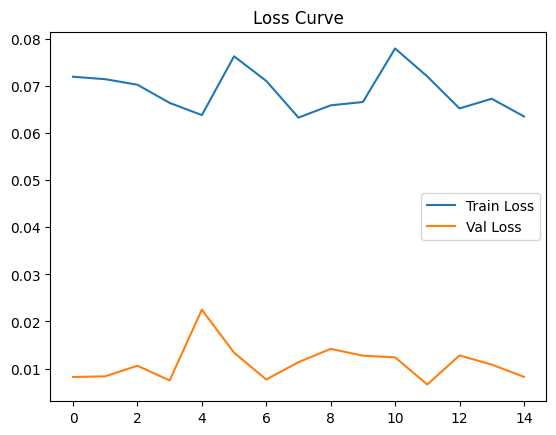

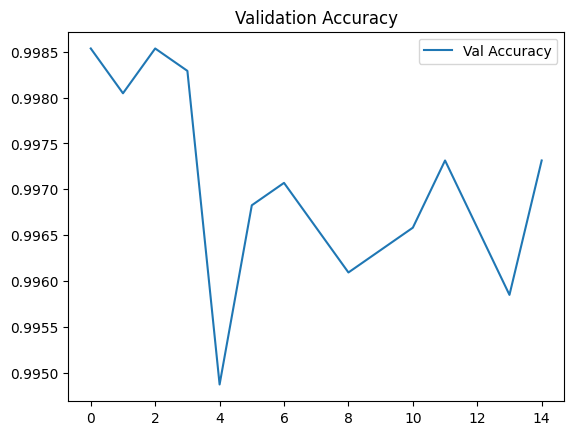

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()
plt.plot(val_accuracies, label="Val Accuracy")
plt.legend()
plt.title("Validation Accuracy")
plt.show()

# Step 8: Show
## 8.1 Load the image

In [ ]:
from PIL import Image

img_path = "/content/drive/MyDrive/Chaetodon_trifascialis.jpg"
fish_img = Image.open(img_path).convert("RGB")

## 8.2 Run the model on the image and print the predicted outcome

In [ ]:
img_tensor = test_transforms(fish_img).unsqueeze(0)
img_tensor = img_tensor.to(device)
model.eval()
with torch.no_grad():
  output = model(img_tensor)

fsh_img, label = torch.max(output, 1)
prediction = train_dataset.classes[label.item()]
print("Predicted fish class:", prediction)


Predicted fish class: 06_chaetodon_trifascial


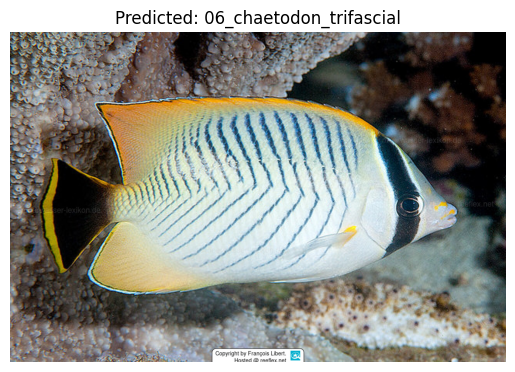

In [ ]:
plt.imshow(fish_img)
plt.title(f"Predicted: {prediction}")
plt.axis("off")
plt.show()

##